In [41]:
# 미세먼지 데이터
pm10_data = [500, 29, 29, 155, 29, 29, 29, 42, 201, 42, 42, 22, 42, 29, 29, 99, 29, 29, 
29, 150, 165, 268, 263, 258, 254, 254, 191, 121, 45, 89, 76, 32, 78, 98, 11, 24, 53,78, 
94]

# 초미세먼지 데이터
pm25_data = [295, 115, 111, 108, 168, 155, 147, 140, 130, 125, 160, 111, 99, 105, 88, 
65, 145, 156, 152, 104, 104, 104, 59, 103, 103, 33,  165, 268, 263, 258, 254, 254, 191, 
221, 178]

In [42]:
import pandas as pd

In [43]:
pm10 = pd.Series(pm10_data)
pm25 = pd.Series(pm25_data)

In [44]:
df= pd.DataFrame({
    '미세먼지pm10':pm10,
    '미세먼지pm25':pm25
})

In [45]:
df.head()

,미세먼지pm10,미세먼지pm25
0,500,295.0
1,29,115.0
2,29,111.0
3,155,108.0
4,29,168.0


In [46]:
df.shape

(39, 2)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   미세먼지pm10  39 non-null     int64  
 1   미세먼지pm25  35 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 756.0 bytes


In [48]:
df.describe()

,미세먼지pm10,미세먼지pm25
count,39.000000,35.000000
mean,103.512821,149.628571
std,103.947323,65.270967
min,11.000000,33.000000
25%,29.000000,104.000000
50%,53.000000,140.000000
75%,152.500000,173.000000
max,500.000000,295.000000


In [49]:
df.isnull().sum()

미세먼지pm10    0
미세먼지pm25    4
dtype: int64

In [50]:
df.isnull().sum().sum() # 전체 데이터 프레임의 결측치

np.int64(4)

In [51]:
df.duplicated().sum() # 중복 행 수

np.int64(0)

In [52]:
# 미세먼지 pm2.5의 평균
df['미세먼지pm25'].mean()

np.float64(149.62857142857143)

In [62]:
df['미세먼지pm25'] = df['미세먼지pm25'].fillna(0) # 결측치를 0으로 채우기

In [64]:
df['미세먼지pm25'] = df['미세먼지pm25'].fillna(df['미세먼지pm25'].mean()) # 평균값으로 채우기

In [55]:
# 미세먼지 10 1사분위 수 (Q1)
q1 = df['미세먼지pm10'].quantile(.25)

# 미세먼지 10 3사분위 수 (Q3)
q3 = df['미세먼지pm10'].quantile(.75)

q1, q3

(np.float64(29.0), np.float64(152.5))

In [56]:
# IQR -> Q3 - Q1
iqr = q3-q1
iqr

np.float64(123.5)

In [57]:
# 하한(최저값)
lower = q1 - 1.5 * iqr

lower

np.float64(-156.25)

In [58]:
# 상한(최대값)
upper = q3 + 1.5 * iqr

upper

np.float64(337.75)

In [59]:
# 이상치
outliers = df[(df['미세먼지pm10'] < lower) | (df['미세먼지pm10'] > upper) ]
outliers

,미세먼지pm10,미세먼지pm25
0,500,295.0


In [60]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\Administrator\bigdata2026\bigdata-base\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\bigdata2026\bigdata-base\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\bigdata2026\bigdata-base\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47676 (\N{HANGUL SYLLABLE MEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\bigdata2026\bigdata-base\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


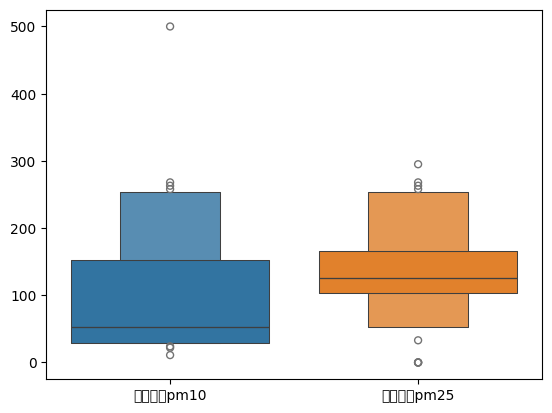

In [65]:
# 박스 플롯 그래프
sns.boxenplot(data=df)
plt.show()